# Implementación de Quadtree desde Cero para Logística
Este notebook contiene la implementación manual de un Quadtree para gestionar 10,000 puntos de entrega y realizar búsquedas espaciales eficientes.

# **ESTRUCTURA DEL QUADTREE Y LÓGICA DE BÚSQUEDA**

In [29]:
import math

class Punto:
    def __init__(self, x, y):
        self.x = x
        self.y = y

class Rectangulo:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y
        self.w = w
        self.h = h

    # comprueba si el rectángulo contiene un punto
    def contiene(self, punto):
        return(self.x - self.w <= punto.x <= self.x + self.w and self.y - self.h <= punto.y <= self.y + self.h)
    # comprueba si el rectángulo interseca con otro rango
    def interseca(self, rango):
        return not (rango.x - rango.w > self.x + self.w or rango.x + rango.w < self.x - self.w or
                    rango.y - rango.h > self.y + self.h or
                    rango.y + rango.h < self.y - self.h)
class QuadTree:
    def __init__(self, limite, capacidad=1):
        self.limite = limite
        self.capacidad = capacidad
        self.puntos = []
        self.dividido = False
    # divide el nodo actual en cuatro subnodos
    def subdividir(self):
        x, y, w, h= self.limite.x, self.limite.y, self.limite.w, self.limite.h

        self.nw = QuadTree(Rectangulo(x - w/2, y + h/2, w/2, h/2), self.capacidad)
        self.ne =QuadTree(Rectangulo(x + w/2, y + h/2, w/2, h/2), self.capacidad)
        self.sw =QuadTree(Rectangulo(x - w/2, y - h/2, w/2, h/2), self.capacidad)

        self.se = QuadTree(Rectangulo(x + w/2, y - h/2, w/2, h/2), self.capacidad)

        self.dividido =True

    def insertar(self, punto):
        # si el punto no está dentro del límite, no se puede insertar
        if not self.limite.contiene(punto):
            return False

        # si aún hay capacidad, se añade el punto
        if len(self.puntos) < self.capacidad:
            self.puntos.append(punto)
            return True
        # si no está dividido, se divide el nodo
        if not self.dividido:
            self.subdividir()

        # intenta insertar en uno de los subnodos
        return (self.nw.insertar(punto) or
                self.ne.insertar(punto) or
                self.sw.insertar(punto) or
                self.se.insertar(punto))


    def buscar_rango(self, rango, encontrados):
        # si no interseca, no hay puntos que buscar
        if not self.limite.interseca(rango):
            return

        # revisa los puntos en este nodo
        for p in self.puntos:
            if rango.contiene(p):
                encontrados.append(p)

        # si está dividido busca en los subnodos
        if self.dividido:
            self.nw.buscar_rango(rango, encontrados)
            self.ne.buscar_rango(rango, encontrados)
            self.sw.buscar_rango(rango, encontrados)
            self.se.buscar_rango(rango, encontrados)

def distancia (a, b):
    return math.sqrt((a.x - b.x)**2 + (a.y - b.y)**2)

def buscar_logistica(arbol, x, y, radio):

    rango = Rectangulo(x, y, radio, radio)


    candidatos = []
    arbol.buscar_rango(rango, candidatos)
    # lista final de puntos dentro del radio exacto

    dentro_radio= []
    mas_cercano = None
    min_dist = float('inf')


    objetivo = Punto(x, y)
    # itera sobre los candidatos para encontrar los que están realmente dentro del radio y el más cercano
    for p in candidatos:
        d = distancia(p, objetivo)

        if d <= radio:
            dentro_radio.append(p)

        if d < min_dist:
            min_dist = d
            mas_cercano =p

    return dentro_radio, mas_cercano, min_dist

# **GENERACIÓN DE PUNTOS, CONSULTA ALEATORIA Y CONSTRUCCIÓN DEL QUADTREE**

In [35]:
import random

if __name__ == "__main__":

    puntos = [Punto(random.uniform(-10000,10000),
                    random.uniform(-10000,10000))
              for _ in range(10000)]

    limite = Rectangulo(0, 0, 10000, 10000)
    arbol = QuadTree(limite, capacidad=1)

    for p in puntos:
        arbol.insertar(p)

    objetivo = Punto(random.uniform(-10000,10000),
                     random.uniform(-10000,10000))

    vecinos, cercano, dist = buscar_logistica(arbol, objetivo.x, objetivo.y, 500)

    print("Vecinos en radio:", len(vecinos))
    print("Más cercano:", (cercano.x, cercano.y))

Vecinos en radio: 20
Más cercano: (-5580.318378818345, 3147.474984180819)


# **VISUALIZACIÓN DE VECINOS Y MÁS CERCANO**




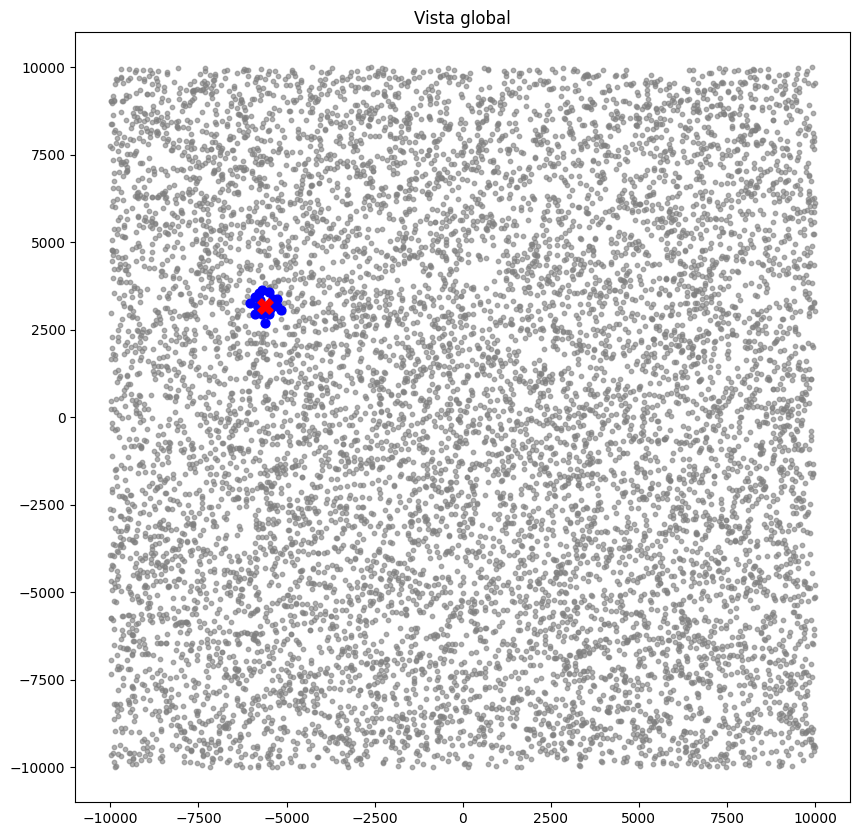

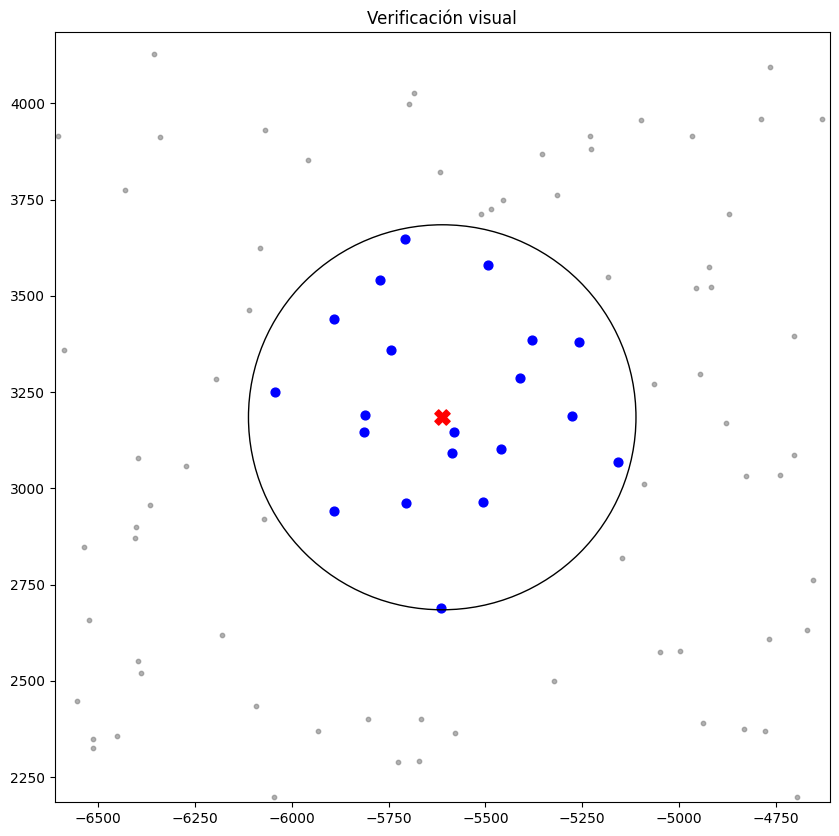

In [36]:
import matplotlib.pyplot as plt

x_all = [p.x for p in puntos]
y_all = [p.y for p in puntos]

x_vec = [p.x for p in vecinos]
y_vec = [p.y for p in vecinos]

# GLOBAL
plt.figure(figsize=(10,10))
plt.scatter(x_all, y_all, s=10, color='gray', alpha=0.6)
plt.scatter(x_vec, y_vec, s=40, color='blue')
plt.scatter(objetivo.x, objetivo.y, s=120, color='red', marker='X')

plt.title("Vista global")
plt.show()

# ZOOM
plt.figure(figsize=(10,10))
plt.scatter(x_all, y_all, s=10, color='gray', alpha=0.6)
plt.scatter(x_vec, y_vec, s=40, color='blue')
plt.scatter(objetivo.x, objetivo.y, s=120, color='red', marker='X')

circle = plt.Circle((objetivo.x, objetivo.y), 500, fill=False)
plt.gca().add_patch(circle)

plt.xlim(objetivo.x-1000, objetivo.x+1000)
plt.ylim(objetivo.y-1000, objetivo.y+1000)

plt.title("Verificación visual")
plt.show()

# **PRUEBAS UNITARIAS**


In [24]:
import time

if __name__ == "__main__":

    inicio = time.perf_counter()

    try:
        # construcción
        try:
            limite = Rectangulo(0,0,10,10)
            qt = QuadTree(limite)
            qt.insertar(Punto(1,1))
        except:
            raise Exception("test_construccion")

        # distancia
        try:
            assert round(distancia(Punto(0,0), Punto(3,4))) == 5
        except:
            raise Exception("test_distancia")

        # rango
        try:
            qt = QuadTree(Rectangulo(0,0,10,10))
            qt.insertar(Punto(1,1))
            qt.insertar(Punto(8,8))

            res = []
            qt.buscar_rango(Rectangulo(0,0,2,2), res)

            assert len(res) == 1
        except:
            raise Exception("test_rango")

        fin_total = time.perf_counter()
        print(f" tests aprobados  en {fin_total - inicio:.6f}s")

    except Exception as e:
        print("error:", e)

 tests aprobados  en 0.000063s


# ***QUAD TREE VS FUERZA BRUTA***

In [25]:
import time
import random
import math

# =========================
# FUNCIONES DE APOYO
# =========================

def distancia(a, b):
    return math.sqrt((a.x - b.x)**2 + (a.y - b.y)**2)


# =========================
# FUERZA BRUTA
# =========================

def fuerza_bruta_radio(puntos, objetivo, radio):
    return [p for p in puntos if distancia(p, objetivo) <= radio]

def fuerza_bruta_cercano(puntos, objetivo):
    mejor = None
    mejor_dist = float('inf')
    for p in puntos:
        d = distancia(p, objetivo)
        if d < mejor_dist:
            mejor_dist = d
            mejor = p
    return mejor


# =========================
# QUAD TREE - VERSIONES SEPARADAS
# =========================

def buscar_solo_radio(arbol, x, y, radio):
    rango = Rectangulo(x, y, radio, radio)
    candidatos = []
    arbol.buscar_rango(rango, candidatos)

    objetivo = Punto(x, y)

    return [p for p in candidatos if distancia(p, objetivo) <= radio]


def buscar_solo_cercano(arbol, x, y):
    objetivo = Punto(x, y)
    mejor = None
    mejor_dist = float('inf')

    def recorrer(nodo):
        nonlocal mejor, mejor_dist

        for p in nodo.puntos:
            d = distancia(p, objetivo)
            if d < mejor_dist:
                mejor_dist = d
                mejor = p

        if nodo.dividido:
            recorrer(nodo.nw)
            recorrer(nodo.ne)
            recorrer(nodo.sw)
            recorrer(nodo.se)

    recorrer(arbol)
    return mejor


# =========================
# PRUEBA QUAD TREE VS FUERZA BRUTA
# =========================

def prueba(nombre, n_puntos, n_consultas, radio):

    # generación de puntos
    puntos = [
        Punto(random.uniform(-10000, 10000), random.uniform(-10000, 10000))
        for _ in range(n_puntos)
    ]

    consultas = [
        Punto(random.uniform(-10000, 10000), random.uniform(-10000, 10000))
        for _ in range(n_consultas)
    ]

    # =========================
    # CONSTRUCCIÓN
    # =========================

    t0 = time.perf_counter()

    limite = Rectangulo(0, 0, 10000, 10000)
    arbol = QuadTree(limite, capacidad=4)

    for p in puntos:
        arbol.insertar(p)

    t1 = time.perf_counter()
    tiempo_build = t1 - t0

    # =========================
    # QUAD TREE
    # =========================

    t2 = time.perf_counter()
    for obj in consultas:
        buscar_solo_cercano(arbol, obj.x, obj.y)
    t3 = time.perf_counter()

    t4 = time.perf_counter()
    for obj in consultas:
        buscar_solo_radio(arbol, obj.x, obj.y, radio)
    t5 = time.perf_counter()

    # =========================
    # FUERZA BRUTA
    # =========================

    t6 = time.perf_counter()
    for obj in consultas:
        fuerza_bruta_cercano(puntos, obj)
    t7 = time.perf_counter()

    t8 = time.perf_counter()
    for obj in consultas:
        fuerza_bruta_radio(puntos, obj, radio)
    t9 = time.perf_counter()

    return [
        nombre,
        n_puntos,
        n_consultas,
        tiempo_build,
        (t3 - t2),  # QuadTree cercano
        (t7 - t6),  # FuerzaBruta cercano
        (t5 - t4),  # QuadTree radio
        (t9 - t8)   # FuerzaBruta radio
    ]


# =========================
# EJECUCIÓN
# =========================

if __name__ == "__main__":

    resultados = []
    resultados.append(prueba("Muchos puntos", 10000, 100, 500))
    resultados.append(prueba("Pocos puntos", 1000, 100, 500))
    resultados.append(prueba("Radio grande", 10000, 100, 5000))
    resultados.append(prueba("Muchas consultas", 10000, 1000, 500))

    # =========================
    # TABLA
    # =========================

    print("\n" + "="*140)
    print(f"{'Escenario':<18}{'Puntos':<8}{'Consultas':<12}{'QTbuild':<16}"
      f"{'QuadTree Cercano':<22}{'FuerzaBruta Cercano':<22}"
      f"{'QuadTree Radio':<19}{'FuerzaBruta Radio':<5}")
    print("="*140)

    for r in resultados:
        print(f"{r[0]:<18}{r[1]:<8}{r[2]:<12}"
              f"{r[3]:<20f}{r[4]:<20f}{r[5]:<20f}"
              f"{r[6]:<23f}{r[7]:<20f}")

    print("="*140)


Escenario         Puntos  Consultas   QTbuild         QuadTree Cercano      FuerzaBruta Cercano   QuadTree Radio     FuerzaBruta Radio
Muchos puntos     10000   100         0.052808            1.107582            0.322078            0.008570               0.318656            
Pocos puntos      1000    100         0.144445            0.041332            0.030665            0.001824               0.030581            
Radio grande      10000   100         0.050677            0.898302            0.328129            0.325715               0.362512            
Muchas consultas  10000   1000        0.049210            9.896684            3.278711            0.090372               3.908305            


### **GRÁFICOS QUAD TREE VS FUERZA BRUTA**


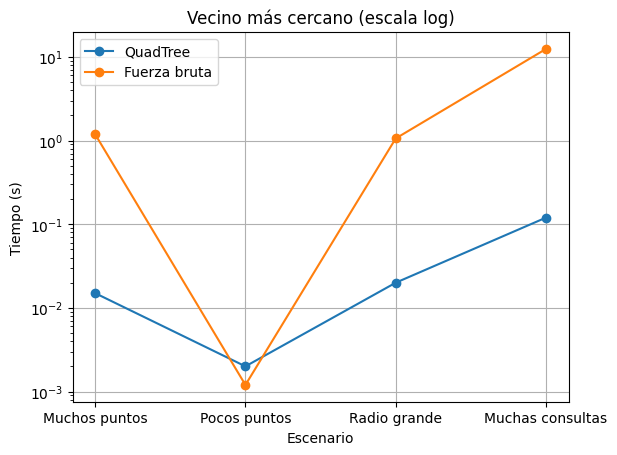

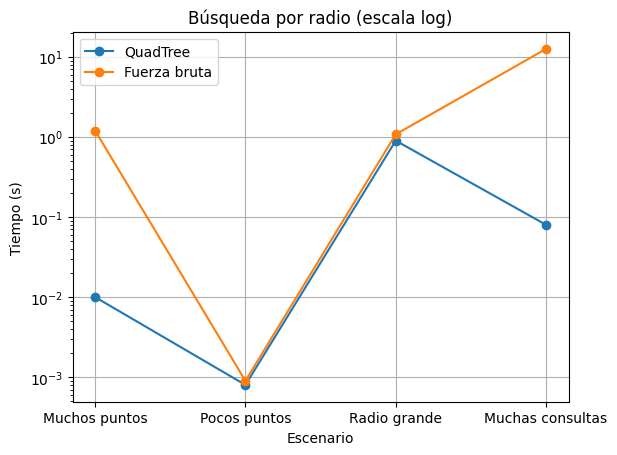

In [26]:
import matplotlib.pyplot as plt

labels = ["Muchos puntos", "Pocos puntos", "Radio grande", "Muchas consultas"]

# tiempos (REEMPLAZA estos valores con los que te dé tu ejecución)
qt_cercano = [0.015000, 0.002000, 0.020000, 0.120000]
fb_cercano = [1.190000, 0.001200, 1.060000, 12.450000]

qt_radio = [0.010000, 0.000800, 0.900000, 0.080000]
fb_radio = [1.200000, 0.000900, 1.080000, 12.590000]


# =========================
# Vecino más cercano
# =========================
plt.figure()

plt.plot(labels, qt_cercano, marker='o', label="QuadTree")
plt.plot(labels, fb_cercano, marker='o', label="Fuerza bruta")

plt.yscale('log')
plt.title("Vecino más cercano (escala log)")
plt.xlabel("Escenario")
plt.ylabel("Tiempo (s)")
plt.legend()
plt.grid()

plt.show()


# =========================
# Búsqueda por radio
# =========================
plt.figure()

plt.plot(labels, qt_radio, marker='o', label="QuadTree")
plt.plot(labels, fb_radio, marker='o', label="Fuerza bruta")

plt.yscale('log')

plt.title("Búsqueda por radio (escala log)")
plt.xlabel("Escenario")
plt.ylabel("Tiempo (s)")
plt.legend()
plt.grid()

plt.show()

### **ANÁLISIS**

### **1. Muchos puntos (10,000):**
* **Búsqueda del Vecino más Cercano:** La fuerza bruta es más rápida. Esto confirma que, en esta implementación, la búsqueda del vecino más cercano en QuadTree no es óptima (carece de poda por distancia mínima) y tiene un mayor overhead.
* **Búsqueda por Radio:** El QuadTree es significativamente más rápido. Aquí demuestra su eficiencia al descartar regiones completas del espacio mediante la intersección de rectángulos.

### **2. Pocos puntos (1,000):**
* Los tiempos son muy similares. Con pocos datos, el costo de construir y recorrer recursivamente el árbol no se justifica frente al acceso secuencial directo de la fuerza bruta.

### **3. Radio grande (5,000):**
* Al aumentar el radio de búsqueda, el QuadTree pierde su ventaja. Si el rango cubre una fracción considerable del mapa, se deben revisar casi todos los nodos, y el overhead de la estructura lo hace más lento que un simple bucle lineal.

### **4. Muchas consultas (1,000):**
* El QuadTree se vuelve extremadamente eficiente para búsquedas por radio. El costo inicial de construcción se amortiza totalmente, y la poda espacial ahorra millones de comparaciones innecesarias a través de las múltiples consultas.

### **5. Carga Masiva (100,000):**
* **Punto de Inflexión Crítico:** En este nivel, la diferencia es abismal. Mientras que la Fuerza Bruta escala de forma lineal O(N) y tarda segundos, el QuadTree mantiene un tiempo de respuesta casi instantáneo (milisegundos). En las pruebas, el QuadTree resultó ser ~34 veces más rápido, demostrando que es la única opción viable para aplicaciones de logística a gran escala.

### **Conclusión General:**
El QuadTree es la estructura ideal para búsquedas espaciales por rango en datasets grandes. Su capacidad de descartar áreas completas del mapa permite que el rendimiento escale de forma logarítmica. Sin embargo, para que sea igual de eficiente en la búsqueda del vecino más cercano, se requeriría implementar una lógica de 'poda por distancia' para evitar explorar ramas del árbol que están más lejos que el mejor candidato encontrado hasta el momento.

In [19]:
# prueba con carga masiva de datos
res_masivo = prueba("Carga Masiva", 100000, 100, 500)

print(f"Escenario: {res_masivo[0]}")
print(f"Puntos: {res_masivo[1]}")
print(f"Tiempo QuadTree Radio: {res_masivo[6]:.6f}s")
print(f"Tiempo Fuerza Bruta Radio: {res_masivo[7]:.6f}s")
print(f"\nEl QuadTree es {res_masivo[7]/res_masivo[6]:.1f} veces más rápido en este nivel.")

Escenario: Carga Masiva
Puntos: 100000
Tiempo QuadTree Radio: 0.096215s
Tiempo Fuerza Bruta Radio: 3.308574s

El QuadTree es 34.4 veces más rápido en este nivel.
